In [1]:
# Rainfall Analysis using NetCDF & Geospatial Data
# Author: Amit Kumar Dubey

In [4]:
import xarray as xr
import rioxarray
import os

file = "C:/Users/kaush.ADMIN/Downloads/precip_2004.nc"

if os.path.exists(file):
    ds = xr.open_dataset(file)
    print("Dataset loaded successfully")
else:
    print("File not found:", file)

Dataset loaded successfully


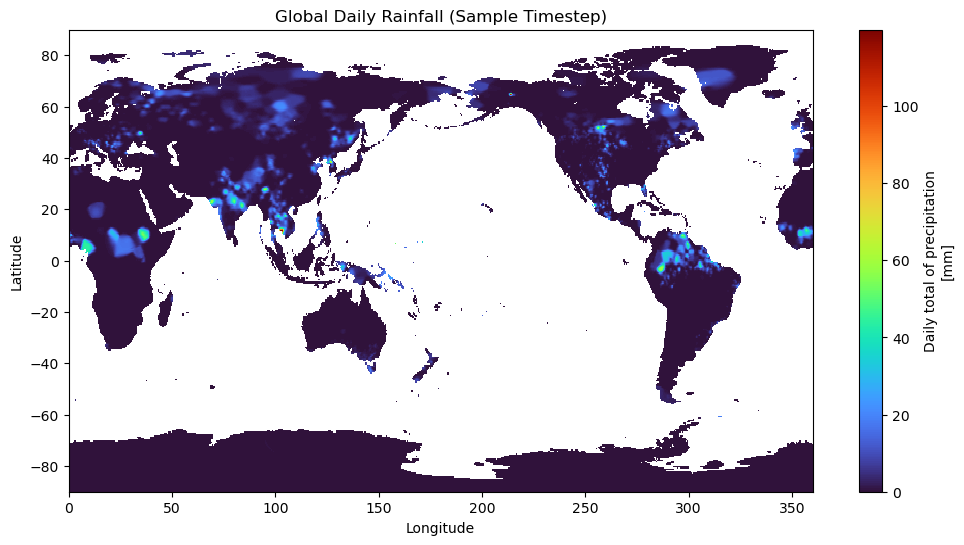

In [5]:
# -----------------------------------
# Step: Global Rainfall Visualization
# -----------------------------------

import matplotlib.pyplot as plt

# Select rainfall variable for a sample timestep
rain = ds["precip"].isel(time=220)

# Plot
plt.figure(figsize=(12,6))
rain.plot(cmap="turbo")

# Labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Global Daily Rainfall (Sample Timestep)")

plt.show()

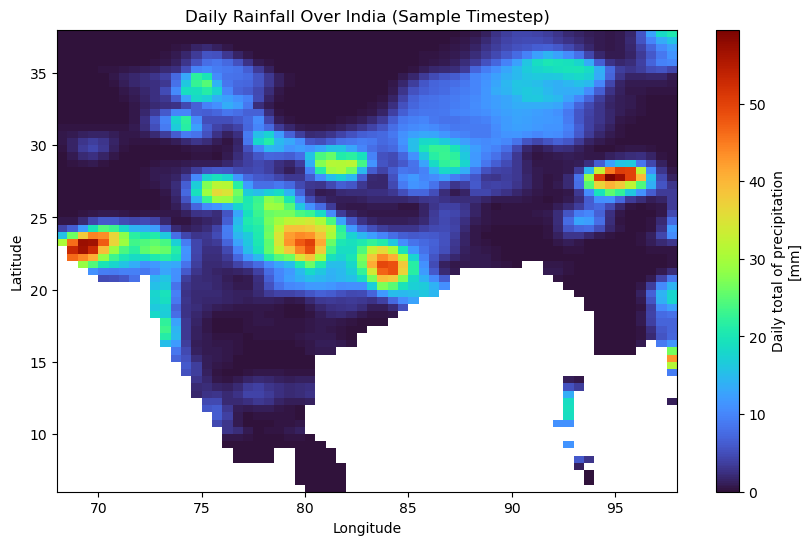

In [6]:
# -------------------------------
# Step: India Rainfall Extraction
# -------------------------------

import matplotlib.pyplot as plt

# Extract India region using lat-lon bounds
india = ds.sel(lat=slice(38, 6), lon=slice(68, 98))

# Select a sample timestep
rain_india = india["precip"].isel(time=220)

# Plot
plt.figure(figsize=(10,6))
rain_india.plot(cmap="turbo")

# Labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Daily Rainfall Over India (Sample Timestep)")

plt.show()

In [7]:
ds = ds.rio.write_crs("EPSG:4326")

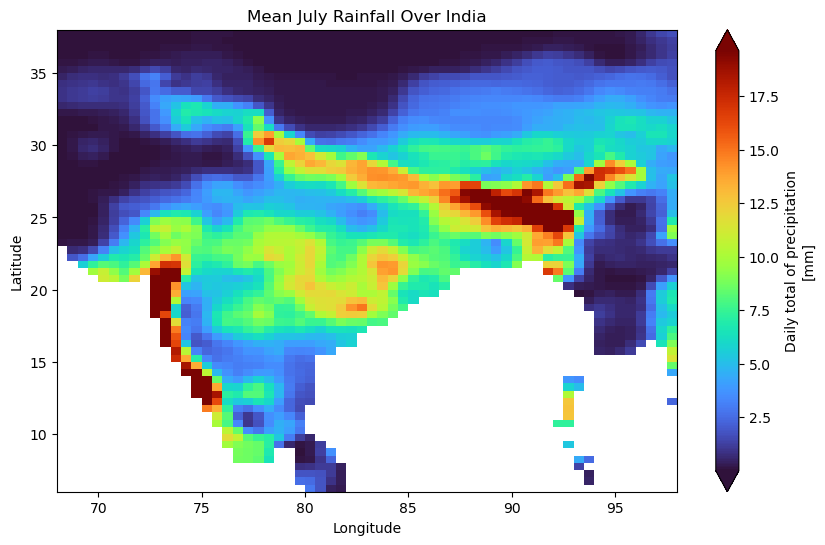

In [8]:
# -------------------------------
# Step: Mean July Rainfall (India)
# -------------------------------

import matplotlib.pyplot as plt

# India region
india = ds.sel(lat=slice(38, 6), lon=slice(68, 98))

# Filter July data
july = india.sel(time=india['time'].dt.month == 7)

# Compute mean rainfall
july_mean = july['precip'].mean(dim='time')

# Plot
plt.figure(figsize=(10,6))
july_mean.plot(cmap="turbo", robust=True)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean July Rainfall Over India")

plt.show()


Index(['dtname', 'stname', 'stcode11', 'dtcode11', 'year_stat', 'Shape_Leng',
       'Shape_Area', 'OBJECTID', 'test', 'Dist_LGD', 'State_LGD', 'geometry'],
      dtype='object')


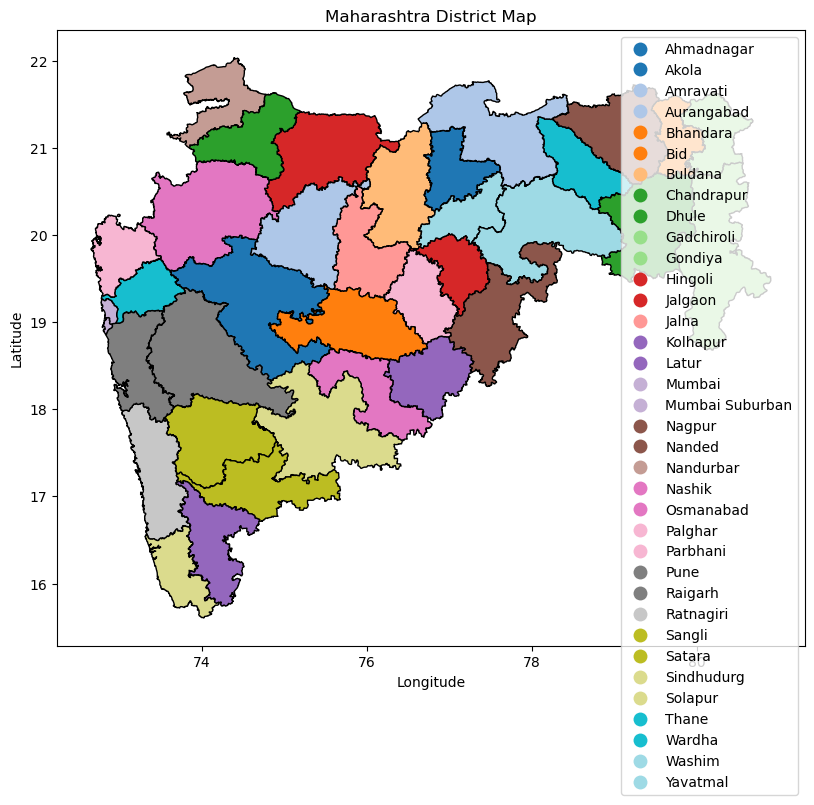

In [9]:
# -----------------------------------
# Step: Load Maharashtra Shapefile
# -----------------------------------

import geopandas as gpd
import matplotlib.pyplot as plt

# Load shapefile
file = "C:/Users/kaush.ADMIN/Downloads/maharashtra_shapefile/maharashtra.shp"
maharashtra = gpd.read_file(file)

# Check columns
print(maharashtra.columns)

# Convert CRS if needed
if maharashtra.crs != "EPSG:4326":
    maharashtra = maharashtra.to_crs("EPSG:4326")

# Plot districts
maharashtra.plot(
    column="dtname",   # change if needed
    cmap="tab20",
    figsize=(12,8),
    legend=True,
    edgecolor="black"
)

plt.title("Maharashtra District Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [10]:
rain = ds["precip"].isel(time=219)

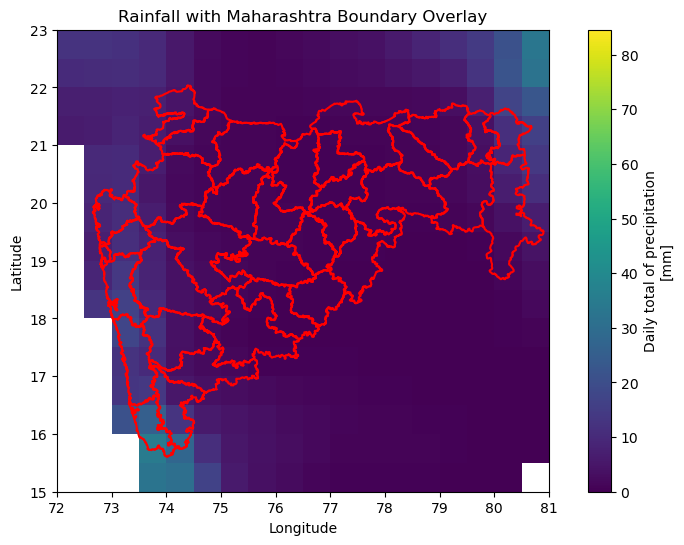

In [11]:
import matplotlib.pyplot as plt

# India subset (important)
india = ds.sel(lat=slice(38, 6), lon=slice(68, 98))
rain = india["precip"].isel(time=219)

plt.figure(figsize=(10,6))

# Plot rainfall
rain.plot(cmap="viridis")

# Overlay Maharashtra boundary
maharashtra.boundary.plot(ax=plt.gca(), color="red", linewidth=1.5)

# Zoom to Maharashtra
plt.xlim(72, 81)
plt.ylim(15, 23)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Rainfall with Maharashtra Boundary Overlay")

plt.show()


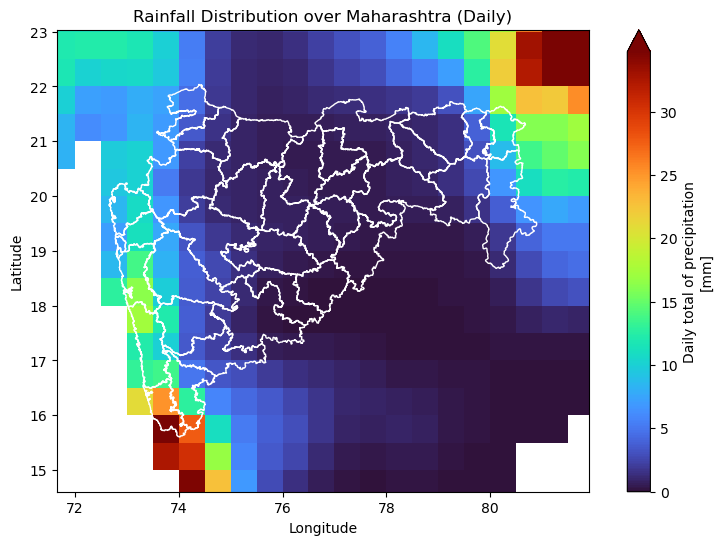

In [13]:
# -----------------------------------------------
# Step: Rainfall + Maharashtra Overlay
# -----------------------------------------------

plt.figure(figsize=(10,6))

# Plot rainfall raster data
rain.plot(cmap="turbo", robust=True)

# Overlay Maharashtra district boundaries
maharashtra.boundary.plot(ax=plt.gca(), color="white", linewidth=1)

# Get bounding box
minx, miny, maxx, maxy = maharashtra.total_bounds

# Zoom to Maharashtra region
plt.xlim(minx-1, maxx+1)
plt.ylim(miny-1, maxy+1)

# Labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Rainfall Distribution over Maharashtra (Daily)")

plt.show()

In [15]:
maha_clip = rain.rio.clip(maharashtra.geometry, maharashtra.crs)

data_min = maha_clip.min().item()
data_max = maha_clip.max().item()

print(data_min, data_max)

0.10775569826364517 34.81523132324219


Min rainfall: 1.986976981163025
Max rainfall: 29.815149307250977


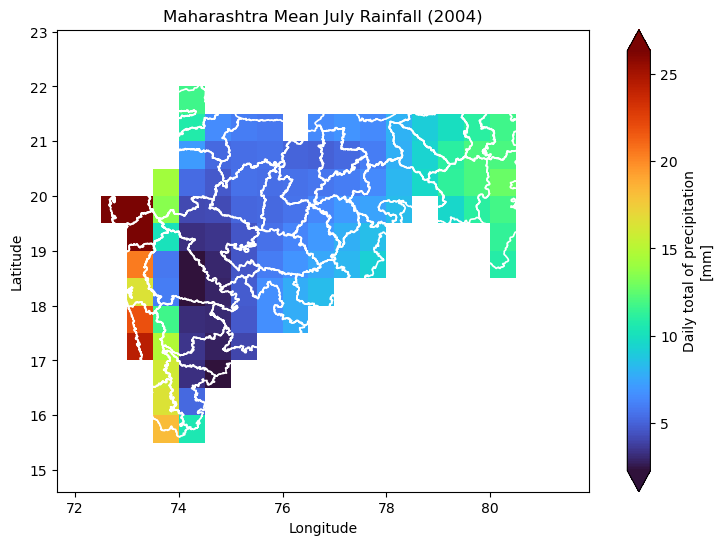

In [16]:
# -----------------------------------------------
# Step: Mean July Rainfall (Maharashtra Clipping)
# -----------------------------------------------

import matplotlib.pyplot as plt

# Step 1: Filter July data
july = ds.sel(time=ds["time"].dt.month == 7)

# Step 2: Compute mean rainfall
july_mean = july["precip"].mean(dim="time")

# Step 3: Clip to Maharashtra boundary
maha_clip = july_mean.rio.clip(maharashtra.geometry, maharashtra.crs)

# Step 4: Check data range (IMPORTANT)
data_min = float(maha_clip.min())
data_max = float(maha_clip.max())
print("Min rainfall:", data_min)
print("Max rainfall:", data_max)

# Step 5: Plot
plt.figure(figsize=(10,6))
maha_clip.plot(cmap="turbo", robust=True)

# Step 6: Overlay boundary
maharashtra.boundary.plot(ax=plt.gca(), color="white", linewidth=1.2)

# Step 7: Zoom
minx, miny, maxx, maxy = maharashtra.total_bounds
plt.xlim(minx - 1, maxx + 1)
plt.ylim(miny - 1, maxy + 1)

# Step 8: Labels & title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Maharashtra Mean July Rainfall (2004)")

plt.show()

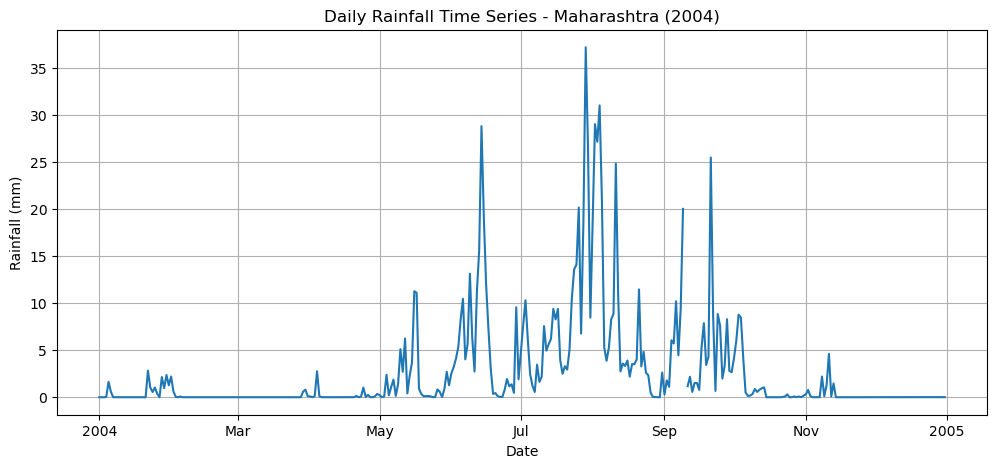

In [17]:
# -----------------------------------------------
# Step: Maharashtra Rainfall Time-Series Analysis
# -----------------------------------------------

import matplotlib.pyplot as plt

# Ensure CRS is set for raster data
ds = ds.rio.write_crs("EPSG:4326", inplace=True)

# Step 1: Clip full rainfall dataset to Maharashtra
maharashtra_clip_full = ds["precip"].rio.clip(
    maharashtra.geometry, maharashtra.crs
)

# Step 2: Compute spatial mean (lat, lon → single value per time)
maharashtra_ts = maharashtra_clip_full.mean(dim=("lat", "lon"))

# Step 3: Plot time-series
plt.figure(figsize=(12,5))
maharashtra_ts.plot()

plt.title("Daily Rainfall Time Series - Maharashtra (2004)")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Date")
plt.grid(True)

plt.show()


In [19]:
minx, miny, maxx, maxy = maharashtra.loc[maharashtra['dtname'] == 'Pune'].total_bounds
print(minx, miny, maxx, maxy)

73.32284797958492 17.89491174272024 75.16428284547624 19.39519250771848


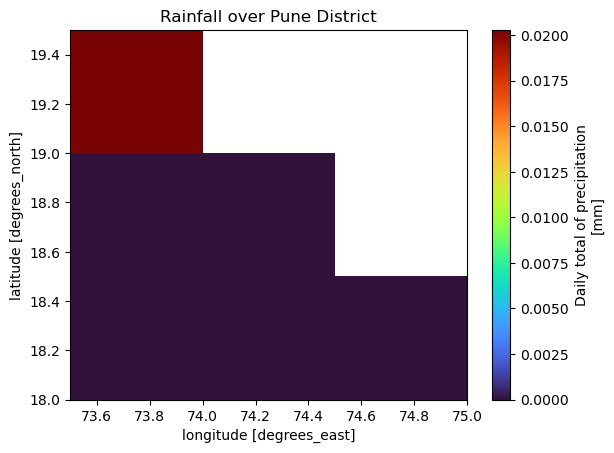

In [21]:
# -----------------------------------
# Step: Pune District Rainfall (Exact)
# -----------------------------------

# Select Pune district geometry
pune = maharashtra[maharashtra["dtname"] == "Pune"]

# Clip rainfall data using exact geometry
rain_pune = ds["precip"].rio.clip(pune.geometry, pune.crs)

# Check output
rain_pune

# Example: extract one timestep
rain_pune_sample = rain_pune.isel(time=365)

# Plot
rain_pune_sample.plot(cmap="turbo")
plt.title("Rainfall over Pune District")
plt.show()

In [22]:
rain_pune.values[365,:3,:3]

array([[0.0202744,       nan,       nan],
       [0.       , 0.       ,       nan],
       [0.       , 0.       , 0.       ]], dtype=float32)

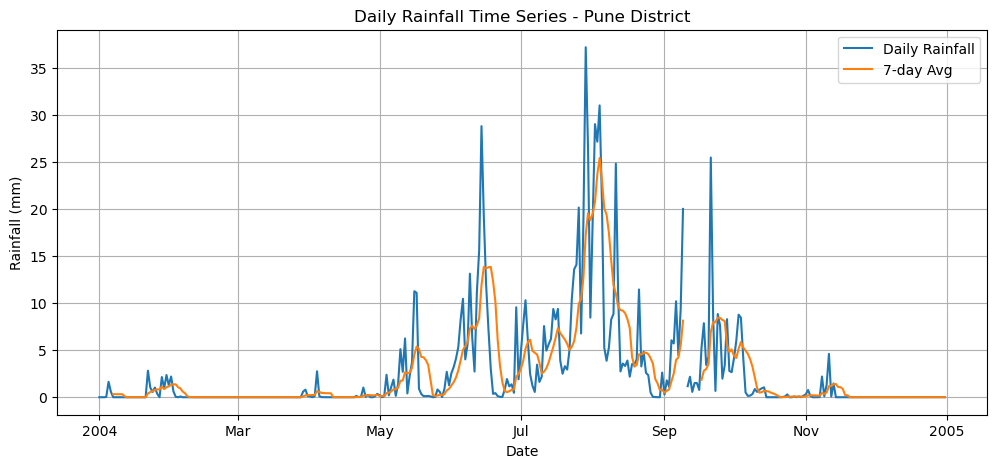

In [24]:
plt.figure(figsize=(12,5))

# Use your actual time series variable
maharashtra_ts.plot(label="Daily Rainfall")
maharashtra_ts.rolling(time=7).mean().plot(label="7-day Avg")

plt.title("Daily Rainfall Time Series - Pune District")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Date")
plt.grid(True)
plt.legend()

plt.show()

In [37]:
import pandas as pd

months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

df_list = []

for dist in district_monthly:
    monthly = district_monthly[dist].values

    row = {"District": dist}
    
    for i, m in enumerate(months):
        row[m] = monthly[i]
    
    df_list.append(row)

df_rain = pd.DataFrame(df_list)
df_rain

,District,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,Gondiya,1.683901,0.123071,0.156334,0.289634,0.451820,6.253583,11.687601,8.510201,3.932616,0.595288,0.317424,0.005894
1,Bhandara,1.608236,0.102978,0.132337,0.272208,0.425619,5.918504,11.333796,8.319297,3.572008,0.518700,0.342764,0.004910
2,Jalgaon,0.265095,0.000324,0.019935,0.000079,1.026492,2.406673,5.510858,4.230286,6.883278,1.635531,0.399917,0.000857
3,Wardha,1.174493,0.147951,0.032584,0.170958,0.453585,4.165268,9.437512,6.724252,2.409474,0.613554,0.507590,0.000000
4,Buldana,0.387589,0.012841,0.048099,0.007409,1.248835,2.383456,5.548490,3.161375,6.504982,1.743663,0.610093,0.000000
5,Akola,0.560228,0.021938,0.070634,0.010853,1.235938,2.683950,5.860665,3.410113,4.305397,1.436653,0.828322,0.000000
6,Nashik,0.120863,0.001588,0.002125,0.001153,1.362302,5.354152,9.782311,11.664037,6.038889,1.315705,0.151350,0.001901
7,Gadchiroli,1.828303,0.509988,0.100977,0.292776,0.487669,4.884538,11.717426,6.807086,3.831611,1.795047,0.210189,0.000863
8,Washim,0.576284,0.067635,0.077068,0.028008,1.247802,2.792264,6.080295,3.289280,4.616119,1.507362,0.763195,0.000000
9,Chandrapur,1.493478,0.391436,0.060495,0.202340,0.404857,4.295696,10.920652,6.985709,2.661407,1.105536,0.355783,0.000112


In [38]:
df_rain.to_csv("maharashtra_district_rainfall.csv", index=False)

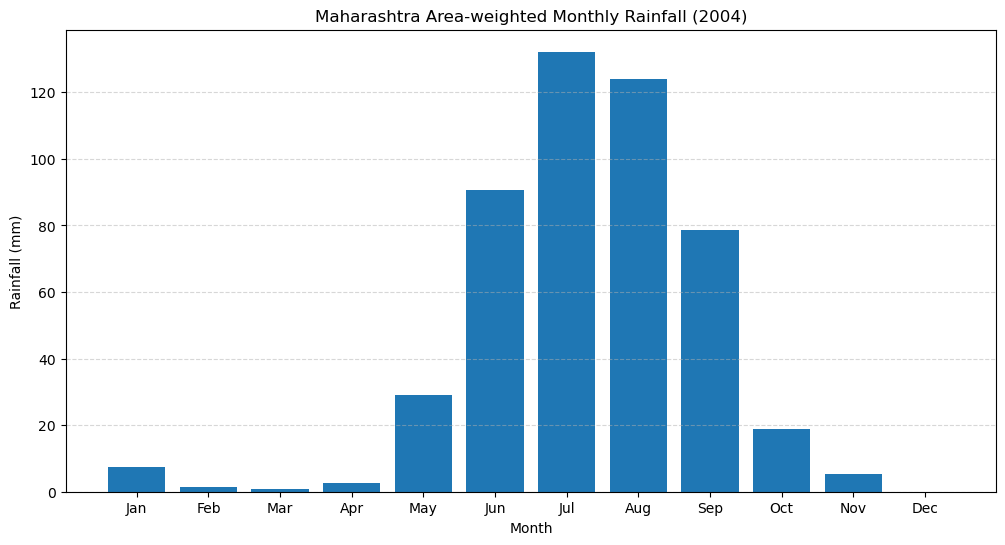

In [41]:
# -----------------------------------------------
# Step: Monthly Area-weighted Rainfall (Maharashtra)
# -----------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Group data by month
monthly = rain_maha.groupby("time.month")

monthly_weighted = []

# Loop through each month
for m in range(1, 13):
    data = monthly[m]

    # Total rainfall for that month
    data_month_total = data.sum(dim="time")

    # Latitude-based weights (cosine weighting)
    weights = np.cos(np.deg2rad(data_month_total["lat"]))

    # Area-weighted mean rainfall
    wmean = data_month_total.weighted(weights).mean(dim=("lat", "lon"))

    monthly_weighted.append(float(wmean.values))

# Month labels
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

# Plot
plt.figure(figsize=(12,6))
plt.bar(months, monthly_weighted)

plt.title("Maharashtra Area-weighted Monthly Rainfall (2004)")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Month")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [42]:
from shapely.geometry import Polygon

# -----------------------------------------------
# Step: Convert grid cell to polygon (lat-lon grid)
# -----------------------------------------------

def grid_to_polygon(lat, lon, res=0.5):
    dx = res / 2
    dy = res / 2

    left   = lon - dx
    right  = lon + dx
    bottom = lat - dy
    top    = lat + dy

    return Polygon([
        (left, bottom),
        (right, bottom),
        (right, top),
        (left, top)
    ])

# Example
poly = grid_to_polygon(20.75, 75.25)
print(poly)

POLYGON ((75 20.5, 75.5 20.5, 75.5 21, 75 21, 75 20.5))


In [64]:
from shapely.geometry import Polygon
import geopandas as gpd

# Create grid polygon
poly = grid_to_polygon(18.75, 73.75)

# Select district safely
dist_geom = maharashtra[maharashtra["dtname"] == "Pune"].geometry.iloc[0]

# Intersection
inter = poly.intersection(dist_geom)

# Convert to projected CRS for correct area
poly_proj = gpd.GeoSeries([poly], crs="EPSG:4326").to_crs("EPSG:6933")
inter_proj = gpd.GeoSeries([inter], crs="EPSG:4326").to_crs("EPSG:6933")




# Area calculation
grid_area = poly_proj.area.values[0]
inter_area = inter_proj.area.values[0]

# Fraction
fraction = inter_area / grid_area

print("Grid area:", grid_area)
print("Intersected area:", inter_area)
print("Fraction:", fraction)

Grid area: 2917983963.638774
Intersected area: 2908564813.1669226
Fraction: 0.9967720348743433


In [50]:
poly_proj = gpd.GeoSeries([poly], crs="EPSG:4326").to_crs("EPSG:6933")
inter_proj = gpd.GeoSeries([inter], crs="EPSG:4326").to_crs("EPSG:6933")

grid_area = poly_proj.area.values[0]
inter_area = inter_proj.area.values[0]

fraction = inter_area / grid_area

print("Grid area (m²):", grid_area)
print("Intersected area (m²):", inter_area)
print("Fraction:", fraction)

Grid area (m²): 2917983963.638774
Intersected area (m²): 2908564813.1669226
Fraction: 0.9967720348743433


In [51]:
# -----------------------------------------------
# Step: Pune July Rainfall (Accurate)
# -----------------------------------------------

# Select Pune district geometry safely
pune_geom = maharashtra[
    maharashtra["dtname"].str.contains("Pune", case=False)
].geometry.iloc[0]

# Extract rainfall variable
rain_full = ds["precip"]

# Filter July data
july_rain = rain_full.sel(time=rain_full.time.dt.month == 7)

# Clip rainfall to Pune district
pune_clip = july_rain.rio.clip([pune_geom], maharashtra.crs)

# Compute mean rainfall
pune_mean = pune_clip.mean(dim=("lat", "lon", "time"))

print("Pune Mean July Rainfall:", float(pune_mean.values), "mm")

Pune Mean July Rainfall: 4.8340229988098145 mm


In [56]:
# -----------------------------------------------
# Step: Extract Monsoon Season (June–September)
# -----------------------------------------------

# Filter monsoon months
monsoon = rain_maha.sel(
    time=(rain_maha.time.dt.month >= 6) & (rain_maha.time.dt.month <= 9)
)

# Total monsoon rainfall
monsoon_total = monsoon.sum(dim="time")

In [58]:
# -----------------------------------------------
# Step: District-wise Monsoon Rainfall
# -----------------------------------------------

district_monsoon = {}

for _, row in maharashtra.iterrows():
    dtname = row["dtname"]
    geom = row.geometry

    try:
        dist_clip = monsoon_total.rio.clip(
            [geom],
            maharashtra.crs,
            drop=False,
            all_touched=True
        )

        if dist_clip.isnull().all():
            print("No data:", dtname)
            continue

        dist_mean = dist_clip.mean(dim=("lat", "lon"), skipna=True)

        district_monsoon[dtname] = float(dist_mean.item())

    except Exception as e:
        print("Error in:", dtname, e)

In [59]:
# Step: Add Monsoon Rainfall to GeoDataFrame
# -----------------------------------------------

maharashtra["MonsoonRain"] = maharashtra["dtname"].map(
    lambda d: district_monsoon.get(d, None)
)

<Figure size 1200x800 with 0 Axes>

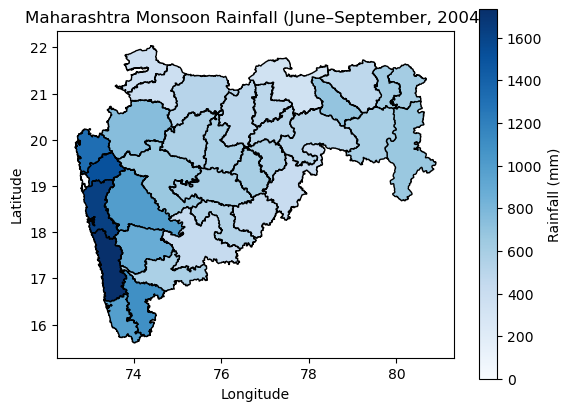

In [60]:
# -----------------------------------------------
# Step: Plot Monsoon Rainfall Map
# -----------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

maharashtra.plot(
    column="MonsoonRain",
    cmap="Blues",
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Rainfall (mm)"}
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Maharashtra Monsoon Rainfall (June–September, 2004)")

plt.show()

In [61]:
# -----------------------------------------------
# Step: Area-weighted Mean Rainfall (Maharashtra)
# -----------------------------------------------

import numpy as np

# Compute latitude-based weights (cosine weighting)
weights = np.cos(np.deg2rad(rain_maha["lat"]))

# Apply weighted mean over spatial dimensions
maha_weighted = rain_maha.weighted(weights).mean(dim=("lat", "lon"))

print("Area-weighted Rainfall (Maharashtra):", float(maha_weighted.mean()), "mm")

Area-weighted Rainfall (Maharashtra): 2.6997931003570557 mm


In [67]:
# Area-weighted rainfall (Maharashtra)
maha_weighted = rain_maha.weighted(weights).mean(dim=("lat", "lon"))

print("Area-weighted Rainfall (Maharashtra):",
      float(maha_weighted.mean(dim="time")), "mm")

Area-weighted Rainfall (Maharashtra): 2.6997931003570557 mm


In [68]:

# -----------------------------------------------
# Step: Monsoon Area-weighted Rainfall
# -----------------------------------------------
# Filter monsoon months
monsoon = rain_maha.sel(
    time=(rain_maha.time.dt.month >= 6) & (rain_maha.time.dt.month <= 9)
)

# Recompute weights
weights = np.cos(np.deg2rad(monsoon["lat"]))

# Total monsoon rainfall (sum over time)
monsoon_total = monsoon.sum(dim="time")

# Area-weighted mean
monsoon_weighted = monsoon_total.weighted(weights).mean(dim=("lat", "lon"))

print("Maharashtra Monsoon Weighted Rainfall:",
      float(monsoon_weighted.values), "mm")

Maharashtra Monsoon Weighted Rainfall: 425.50543212890625 mm


In [74]:
from shapely.geometry import Polygon

# Pune geometry FIX
pune = maharashtra[maharashtra["dtname"] == "Pune"].geometry.iloc[0]

# July subset
july_rain = ds["precip"].sel(time=ds.time.dt.month == 7)

# Coordinates
lat_vals = july_rain["lat"].values
lon_vals = july_rain["lon"].values

# Grid spacing
dy = abs(lat_vals[1] - lat_vals[0]) / 2
dx = abs(lon_vals[1] - lon_vals[0]) / 2

# Grid polygon function
def grid_to_polygon(lat, lon):
    return Polygon([
        (lon - dx, lat - dy),
        (lon + dx, lat - dy),
        (lon + dx, lat + dy),
        (lon - dx, lat + dy)
    ])

# Initialize
pune_total = 0.0
pune_w = 0.0

# Loop
for i, lat in enumerate(lat_vals):
    for j, lon in enumerate(lon_vals):

        cell = grid_to_polygon(lat, lon)

        
        inter = cell.intersection(pune)

        if inter.is_empty:
            continue

        frac = inter.area / cell.area
        rain_val = float(july_rain[:, i, j].mean())

        pune_total += rain_val * frac
        pune_w += frac

# Final
pune_mean = pune_total / pune_w

print("Pune July Weighted Mean Rainfall (mm):", pune_mean)

Pune July Weighted Mean Rainfall (mm): 5.38347278532217
